In [15]:
'''
Data Analysis for the cleaned data
'''


'\nData Analysis for the cleaned data\n'

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/clean/airbnb_cleaningdata.csv")

print(df.head())
print(df.info())

                    id                                            title  \
0  1292713234154945394  ETERNA.Suite W Jaccuzi, Pyramids View & Balcony   
1  1508718511630646313                                 king khufu suite   
2  1297327219631789358                             Akasia Pyramids View   
3  1606001853199411128          Mountain Cave | Pyramids View & Jacuzzi   
4  1314833467096489875                               Heaven of Pyramids   

                                                 url  \
0  https://www.airbnb.com/rooms/12927132341549453...   
1  https://www.airbnb.com/rooms/15087185116306463...   
2  https://www.airbnb.com/rooms/12973272196317893...   
3  https://www.airbnb.com/rooms/16060018531994111...   
4  https://www.airbnb.com/rooms/13148334670964898...   

                                           thumbnail        lat        lng  \
0  https://a0.muscache.com/im/pictures/hosting/Ho...  29.973873  31.146603   
1  https://a0.muscache.com/im/pictures/hosting/Ho...  29

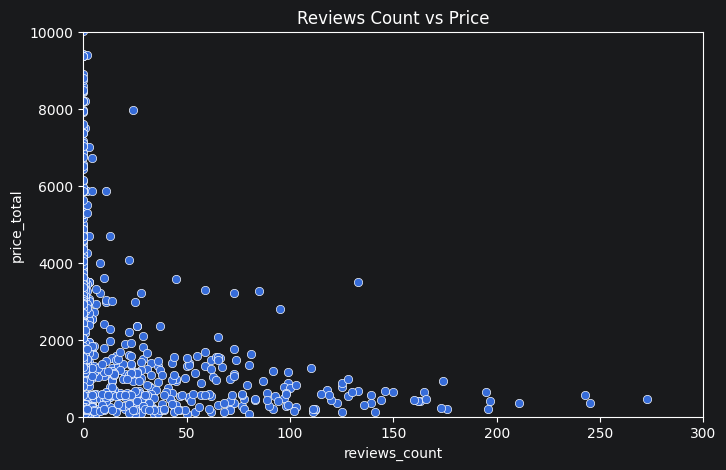

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['reviews_count'], y=df['price_total'])
plt.xlim(0, 300)
plt.ylim(0, 10000)
plt.title("Reviews Count vs Price")
plt.show()

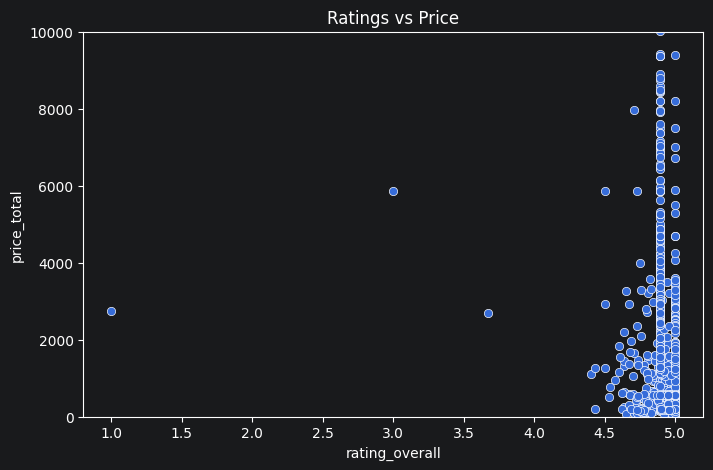

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rating_overall'], y=df['price_total'])
plt.ylim(0, 10000)
plt.title("Ratings vs Price")
plt.show()

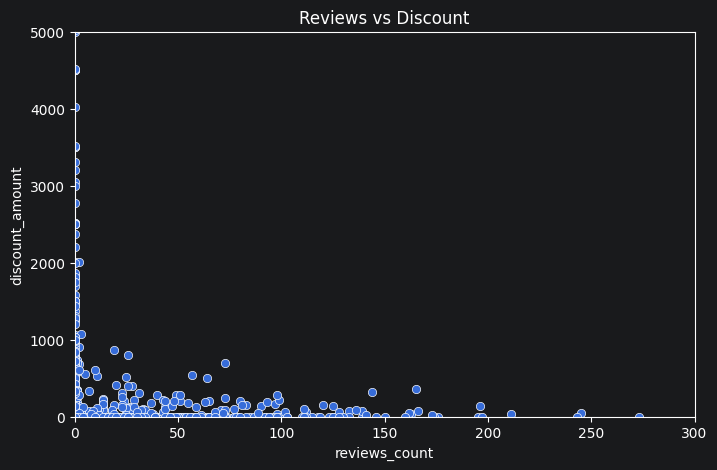

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['reviews_count'], y=df['discount_amount'])
plt.xlim(0, 300)
plt.ylim(0, 5000)
plt.title("Reviews vs Discount")
plt.show()

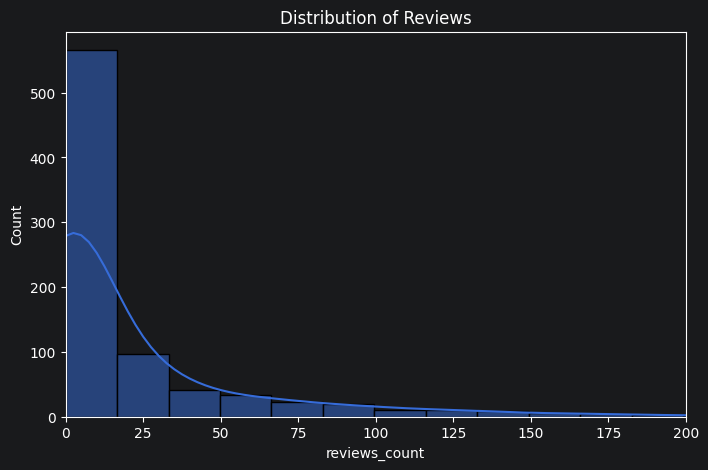

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['reviews_count'], bins=30, kde=True)
plt.xlim(0, 200)
plt.title("Distribution of Reviews")
plt.show()

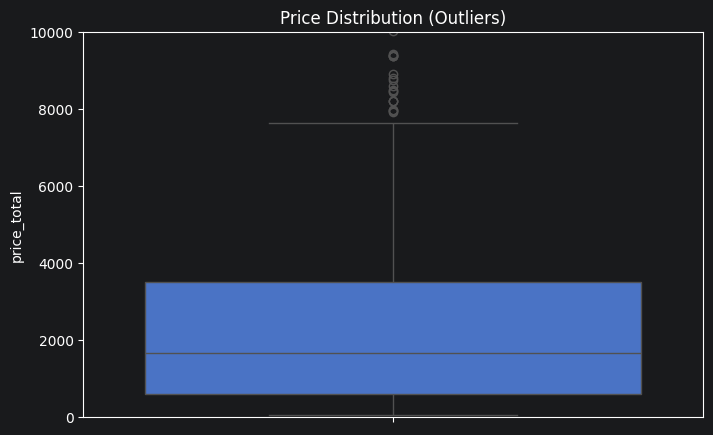

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['price_total'])
plt.ylim(0, 10000)
plt.title("Price Distribution (Outliers)")
plt.show()

In [66]:
import folium
from folium.plugins import HeatMap

# Create base map
m = folium.Map(location=[df['lat'].mean(), df['lng'].mean()], zoom_start=12)

# --- Price layer ---
price_group = folium.FeatureGroup(name="Price Heatmap")
heat_price = list(zip(df['lat'], df['lng'], df['price_total']))
HeatMap(heat_price, radius=15, blur=10, max_zoom=13).add_to(price_group)
price_group.add_to(m)

# --- Reviews layer ---
reviews_group = folium.FeatureGroup(name="Reviews Heatmap", show=False)
heat_reviews = list(zip(df['lat'], df['lng'], df['reviews_count']))
HeatMap(heat_reviews, radius=15, blur=10, max_zoom=13).add_to(reviews_group)
reviews_group.add_to(m)

# --- Toggle control (top right corner) ---
folium.LayerControl().add_to(m)

m.save("cairo_heatmap.html")
m